In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u
# from astropy.constants import k_B, N_A
from astropy.visualization import quantity_support
quantity_support();
from scipy import signal

**1. Расчёт частот, генерируемых таймером Ардуино в режиме CTC**

Частота прерываний при тактовой частоте $F$, коэффициенте $k$ деления предделителя, записанном в компаратор числе $N_{max}$

\begin{equation}
f_{int}=\frac{F}{k \cdot (N_{max} + 1)}
\end{equation}


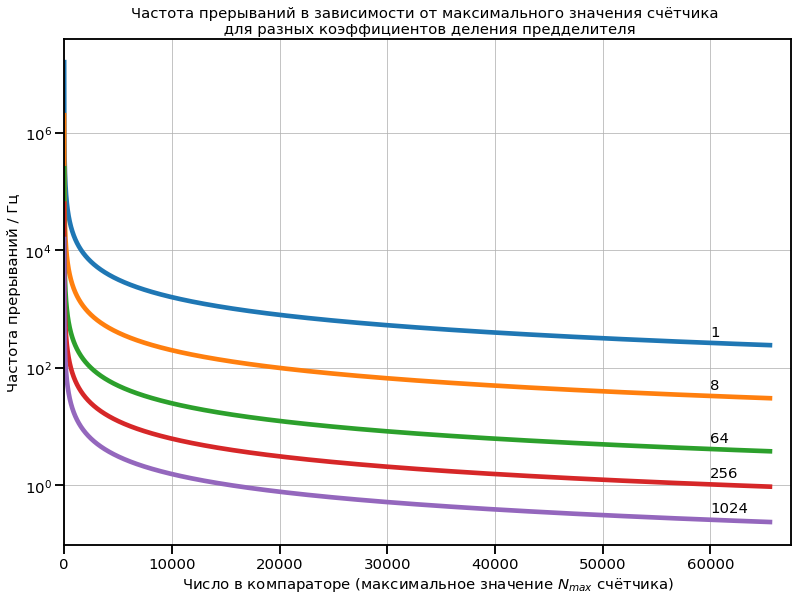

In [9]:
fig = plt.figure(figsize=(14, 10), dpi=67)
ax = fig.add_subplot(111)

F = 16e6 * u.Hz
ks = [1, 8, 64, 256, 1024]
Nmaxs = np.arange(0, 65535)
for k in ks:
    fs = F/ k/ (1 + Nmaxs)
    plt.semilogy(Nmaxs, fs, linewidth=5)
    plt.text(60000, 1.3*fs[60000], k, fontsize=16)
plt.xlim(left=0, right=67500)
plt.xlabel('Число в компараторе (максимальное значение $N_{max}$ счётчика)', fontsize=16)
plt.ylabel('Частота прерываний / Гц', fontsize=16)

plt.tick_params(axis='both', which='major', length=10, width=2, labelsize=16)
plt.tick_params(axis='both', which='minor', length=5, width=1)
plt.grid(True)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.title('Частота прерываний в зависимости от максимального значения счётчика \n для разных коэффициентов деления предделителя', fontsize=16);
plt.savefig('260406_graph.jpg', bbox_inches='tight')

**2. Расчёт $N_{max}$ для заданной выходной частоты $f$ при заданном коэффициенте $k$ деления**
\begin{equation}
N_{max} = \frac{8 \ \mathrm{MHz}}{kf} - 1
\end{equation}
Выходная частота $f$ вдвое ниже частоты прерываний, поэтому в формуле 8 МГц, а не 16.
Следует понимать, что график не сплошная линия, а множество отдельных точек, поэтому не для всякой заданной частоты $f$ найдётся значение $N_{max}$. Формальный расчёт возможен для любой $f$, но результат может не оказаться целым положительным числом, что означает невозможность получить заданную $f$.

In [14]:
# Функция для расчёта начального значения счётчика при заданной частоте f и коэффициенте k деления

def N_max(k, f):
    return 8000000/k/f - 1

N_max(1, 1)

7999999.0

In [19]:
def Nmax_str(k, f):
    Nmax = 8000000/k/f - 1
    intNmax = int(Nmax)
    if Nmax==intNmax and Nmax > -1 and Nmax < 65536 : return ' ' + '{:5d}'.format(intNmax) + ' '
#     str(intNmax) # проверка на целость и положительность
    else: return '       '

Nmax_str(1024, 1)

'       '

In [20]:
# Расчёт максимального значения счётчика при разных коэффициентах деления предделителя
# для получения некоторых частот
# Значения получены в предположении, что на обработку прерывания время не тратится.


c = 6              #количество столбцов в таблице
p = 7              #ширина столбца
line = '─' * ( p*c + c - 1 + 5)    # горизонтальная линия в таблице
print(line)
S = '            '
for k in ks:
    S = S + '|' + ' ' + '{:5d}'.format(k) + ' '
print(S+ '|')    
print(line)

fs = [1, 2, 2.5, 3, 4, 5, 6, 7, 7.5, 8, 9]
scales = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
for scale in scales:
    for f in fs:
        F = f * scale
        S = ' '
        for k in ks:
            S = S + '|' + Nmax_str(k,F)
        S = ' ' + f"{F:10.2f}" + S + '|' # f"{f:.1f} означает: f-строка (первое f), вывести переменную f (второе f)
                                       # типа float (третье f)
        print(S)

# Частота в герцах в левом столбце. 
# Отсутствие в таблице вычисленного начального значения счётчика для данной частоты и коэф-та деления
# означает невозможность получения этой частоты при этом коэф-те        

!python --version

────────────────────────────────────────────────────
            |     1 |     8 |    64 |   256 |  1024 |
────────────────────────────────────────────────────
       0.10 |       |       |       |       |       |
       0.20 |       |       |       |       |       |
       0.25 |       |       |       |       | 31249 |
       0.30 |       |       |       |       |       |
       0.40 |       |       |       |       |       |
       0.50 |       |       |       | 62499 | 15624 |
       0.60 |       |       |       |       |       |
       0.70 |       |       |       |       |       |
       0.75 |       |       |       |       |       |
       0.80 |       |       |       |       |       |
       0.90 |       |       |       |       |       |
       1.00 |       |       |       | 31249 |       |
       2.00 |       |       | 62499 | 15624 |       |
       2.50 |       |       | 49999 | 12499 |  3124 |
       3.00 |       |       |       |       |       |
       4.00 |       |       | 